In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = {}

for h in range(4, 13):
    data[h] = {}

    for t in range(4, 8):
        T = 10**t
        data[h][t] = pd.read_csv(f"last_cont_h{h}_t{T}.dat",sep="\t")

In [1]:


for h in range(4, 13):

    plt.figure()

    for t in range(4, 8):

        cont = data[h][t]

        energy = cont["#Cont  nu"].to_numpy()
        flux = cont["incident"].to_numpy()

        plt.loglog(energy, flux, label=f"T = {10**t:.0e} K")

    plt.xlabel("Wavelength in microns")
    plt.ylabel("Flux")
    plt.title(f"Incident Continuum for hden = {h}")
    plt.legend()
    plt.xlim(1e-1, 1e1)
    plt.ylim(1e30,1e41)
    filename = f"incident_continuum_hden_{h}.png"

    plt.show()

NameError: name 'plt' is not defined

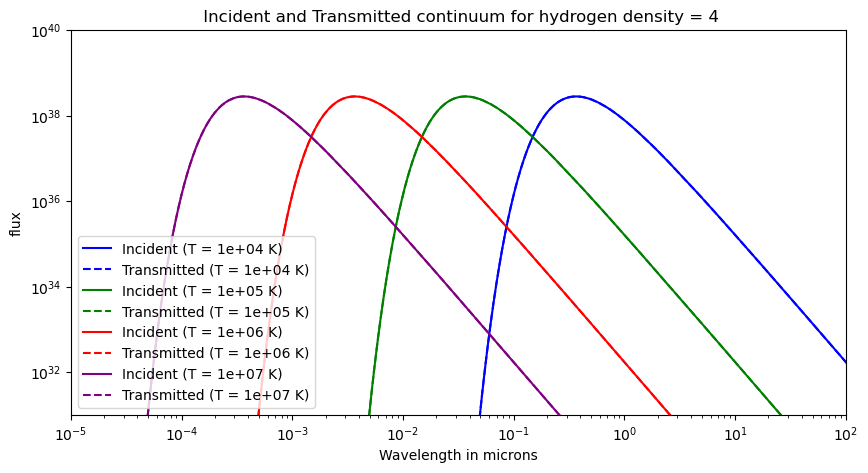

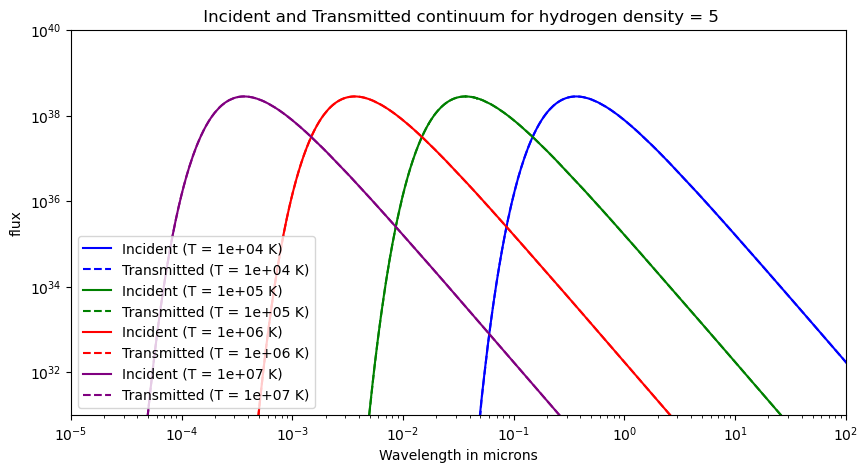

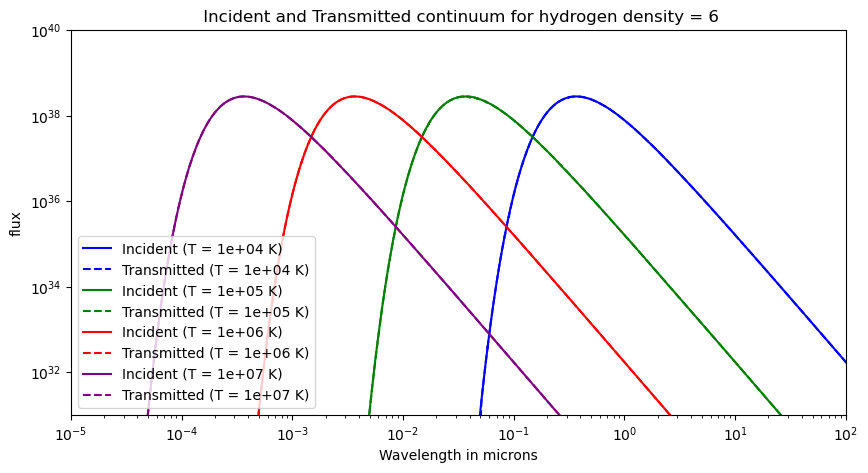

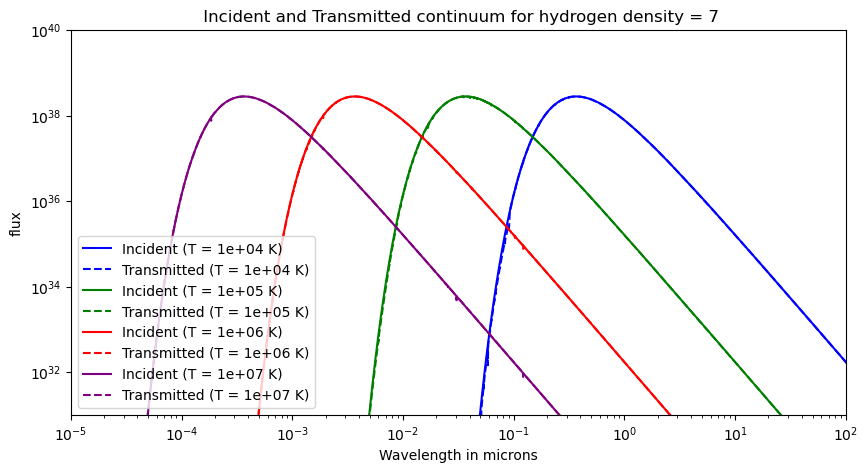

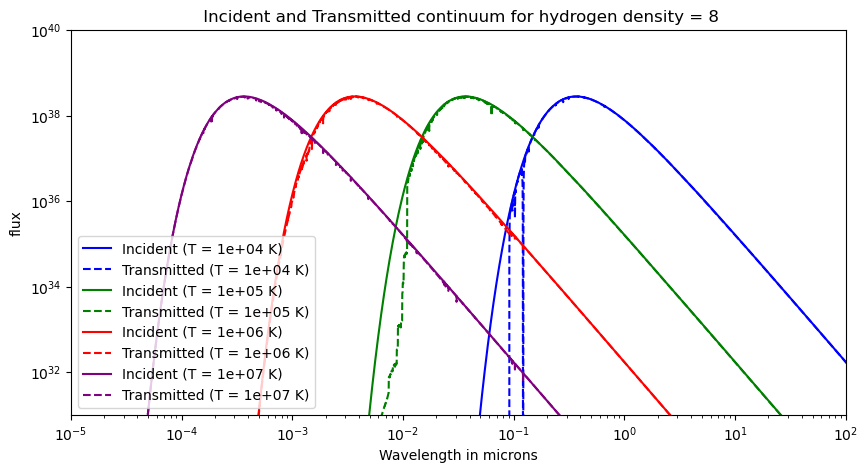

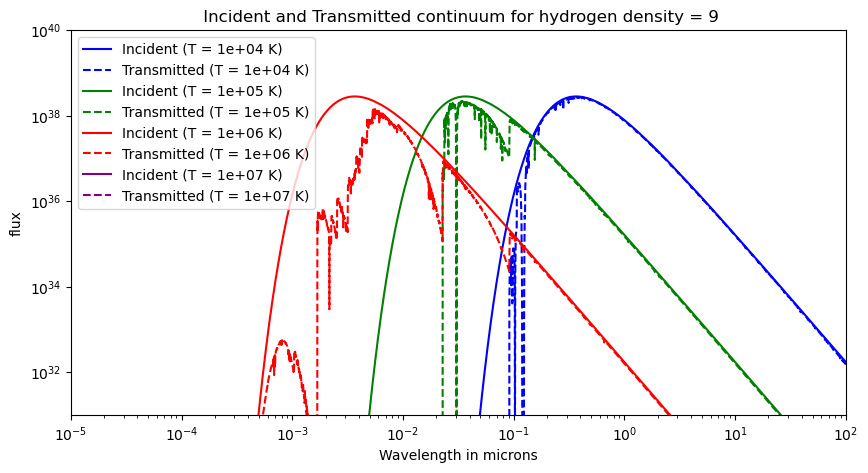

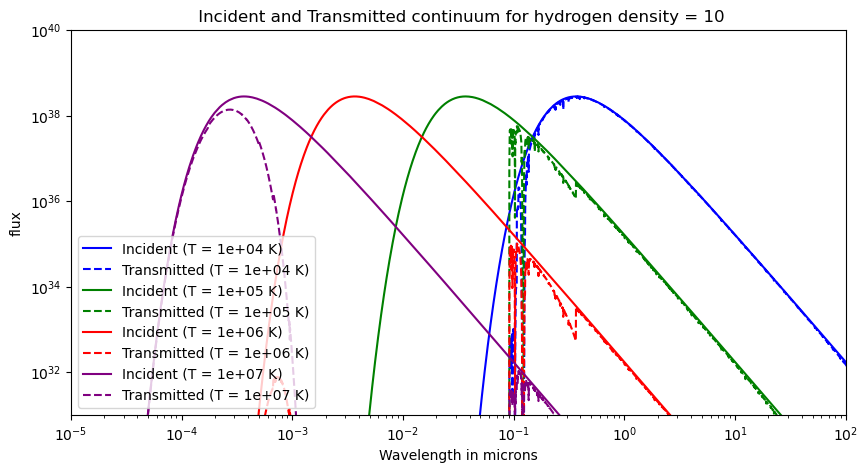

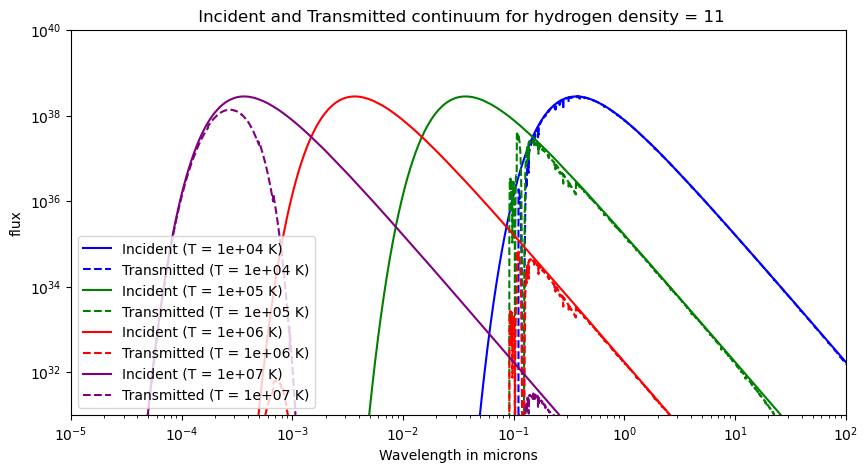

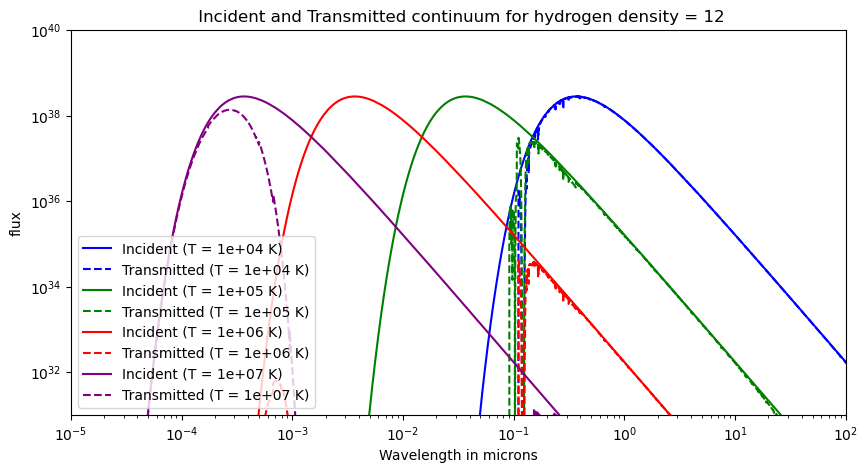

In [5]:
colors = {4: 'blue',5: 'green',6: 'red',7: 'purple'}

for h in range(4, 13):
    plt.figure(figsize = (10,5))
    
    for t in range(4, 8):
        cont = data[h][t]

        energy = cont["#Cont  nu"].to_numpy()
        incident  = cont["incident"].to_numpy()
        transmitted = cont["trans"].to_numpy()
        c = colors[t]

        plt.loglog(energy, incident, linestyle='-',color = c, label=f"Incident (T = {10**t:.0e} K)")
        plt.loglog(energy, transmitted,linestyle='--',color = c, label=f"Transmitted (T = {10**t:.0e} K)")

    plt.ylim(1e31,1e40)
    plt.xlim(1e-5,1e2)

    plt.ylabel("flux")
    plt.xlabel("Wavelength in microns")
    plt.title(f" Incident and Transmitted continuum for hydrogen density = {h}")
    plt.legend()
plt.show()

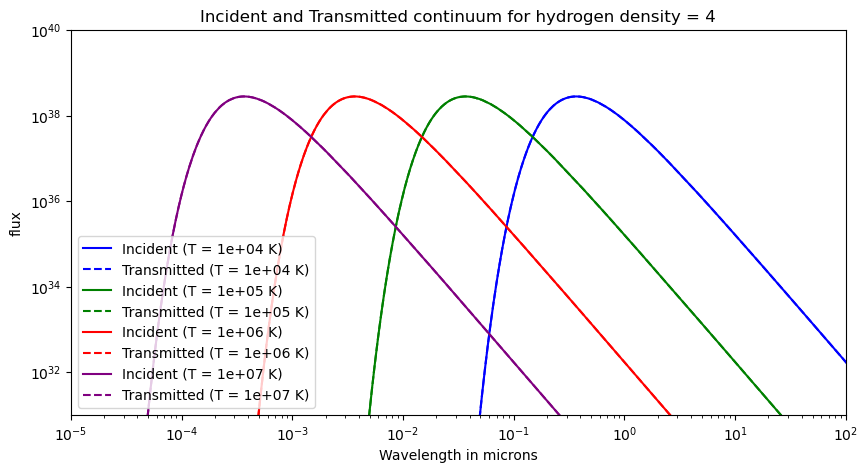

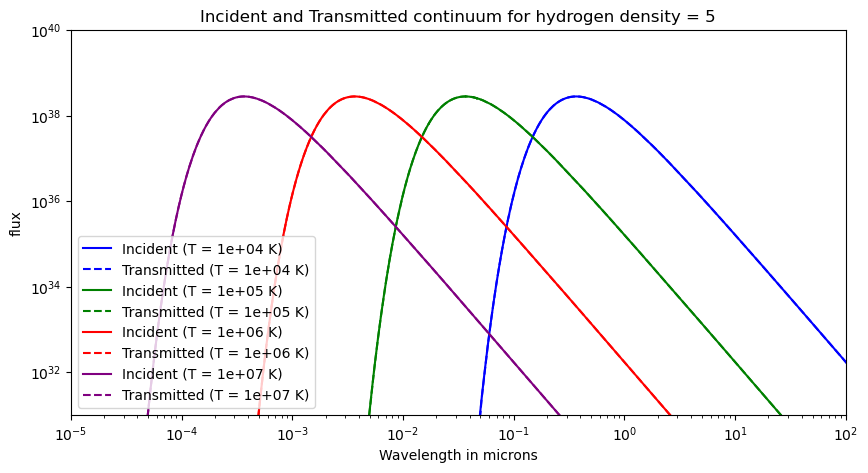

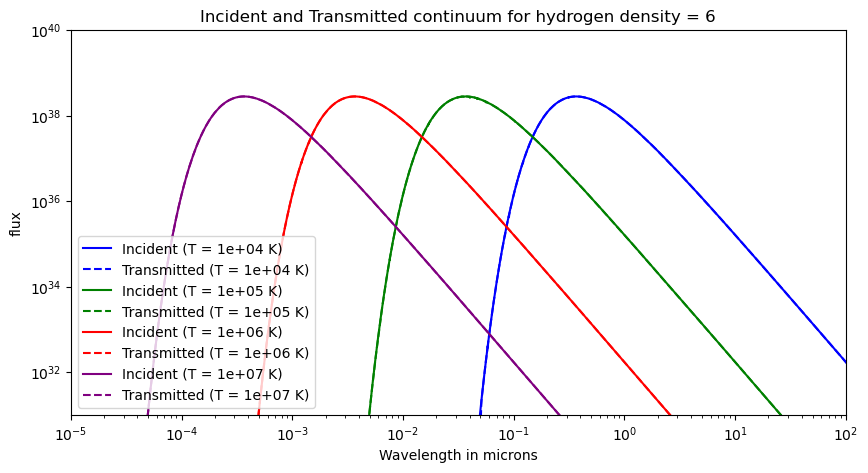

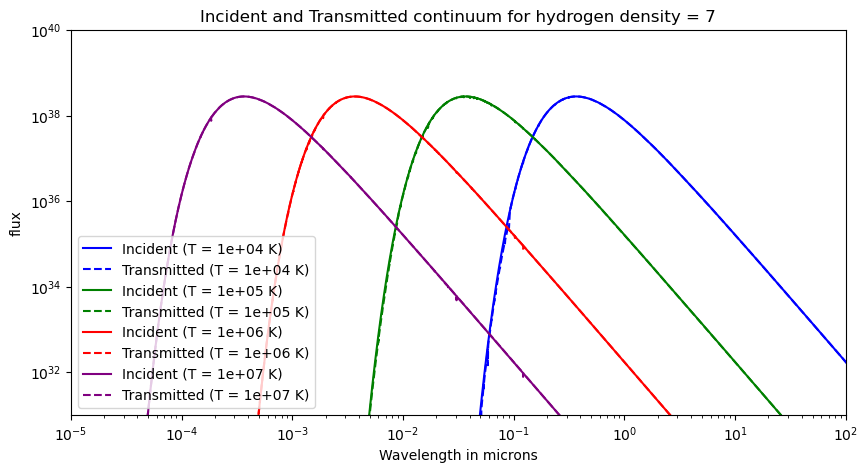

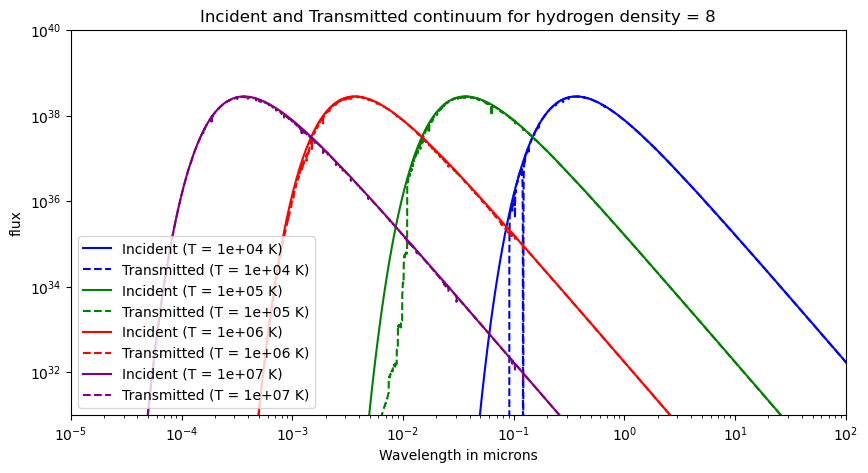

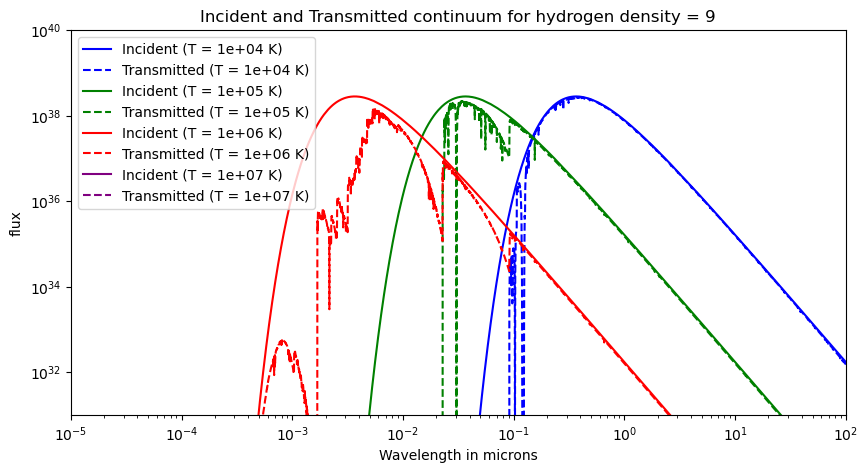

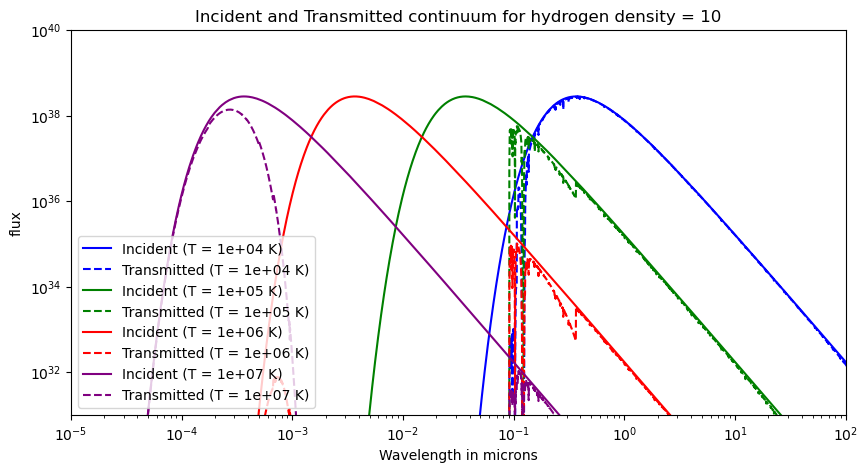

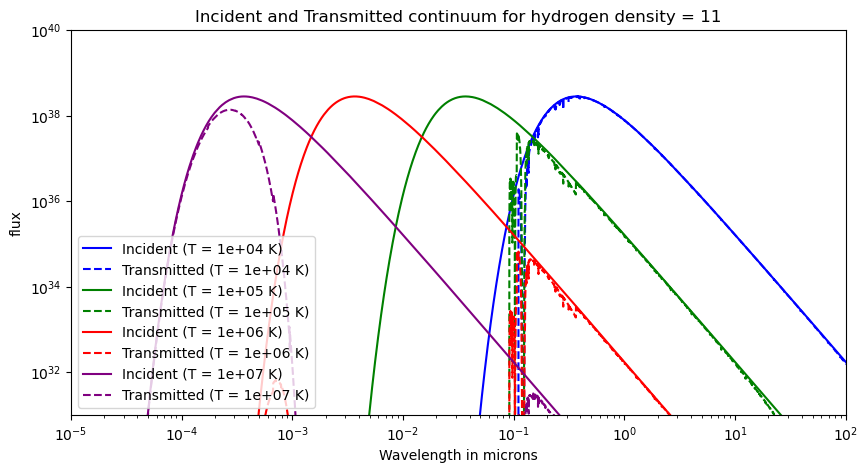

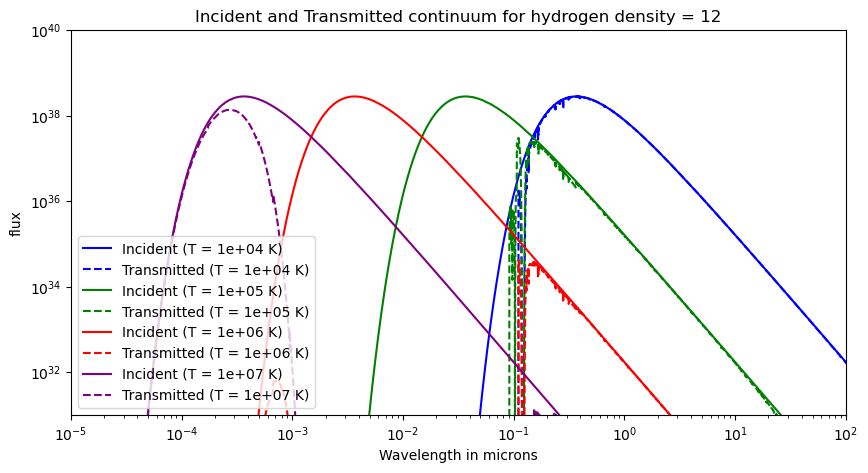

In [9]:
colors = {4: 'blue',5: 'green',6: 'red',7: 'purple'}

for h in range(4, 13):
    
    plt.figure(figsize=(10, 5))
    
    for t in range(4, 8):
        cont = data[h][t].copy()

        energy = cont["#Cont  nu"].to_numpy()
        incident = cont["incident"].to_numpy()
        
        c = colors[t]
        
        cont["trans"] = cont['trans'].replace(0, 1e-20)
        transmitted = cont["trans"].to_numpy()
        
        plt.loglog(energy, incident, linestyle='-',color = c, label=f"Incident (T = {10**t:.0e} K)")
        
        plt.loglog(energy, transmitted, linestyle='--',color = c, label=f"Transmitted (T = {10**t:.0e} K)")

    plt.ylabel("flux")
    plt.xlabel("Wavelength in microns")
    plt.title(f"Incident and Transmitted continuum for hydrogen density = {h}")
    plt.ylim(1e31,1e40)
    plt.xlim(1e-5,1e2)

    plt.legend()
    plt.show() 

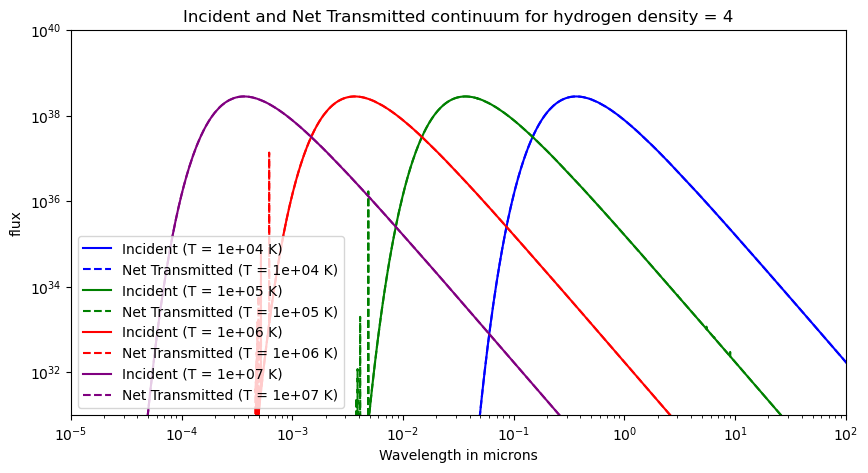

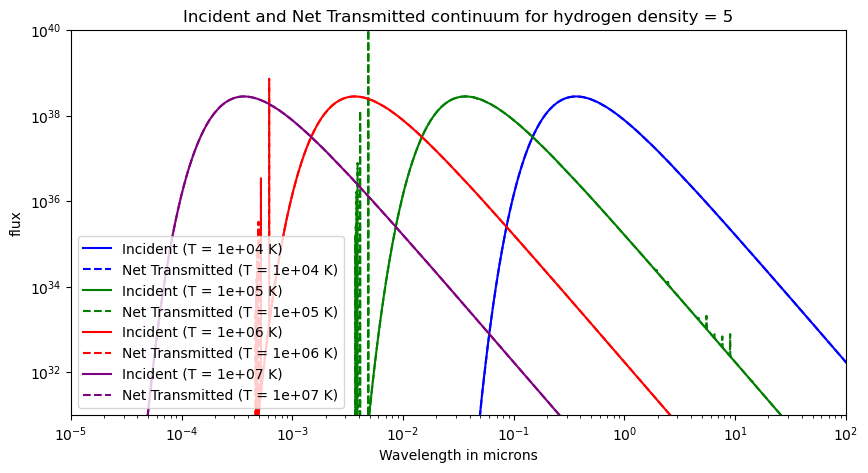

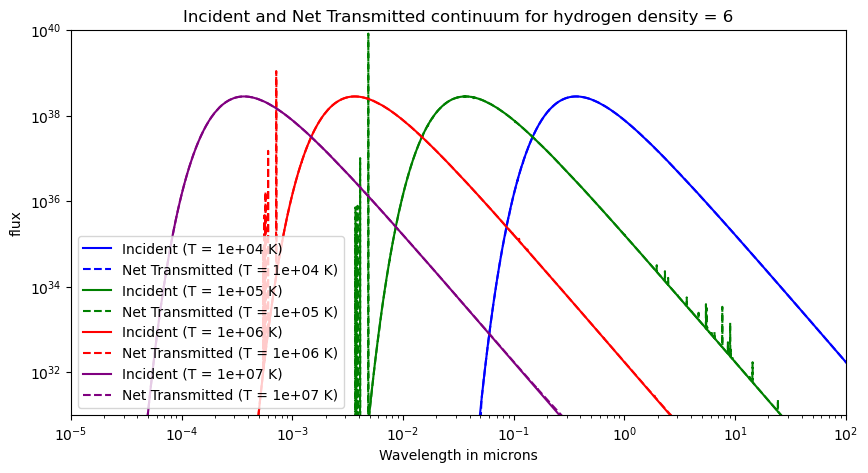

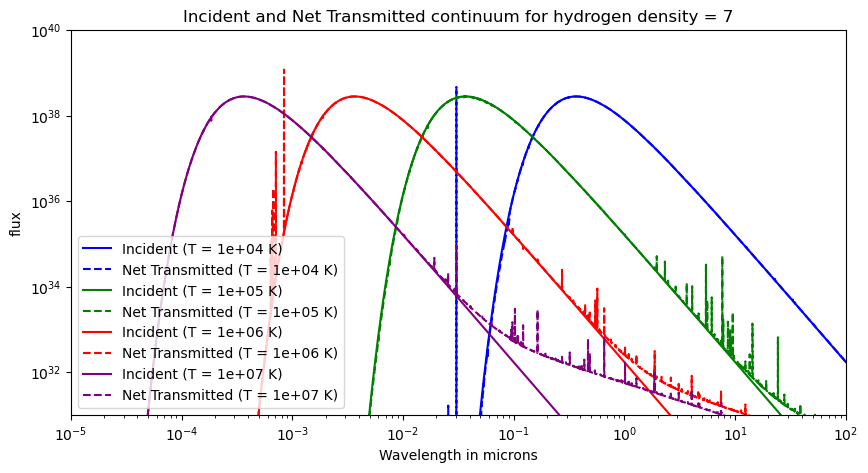

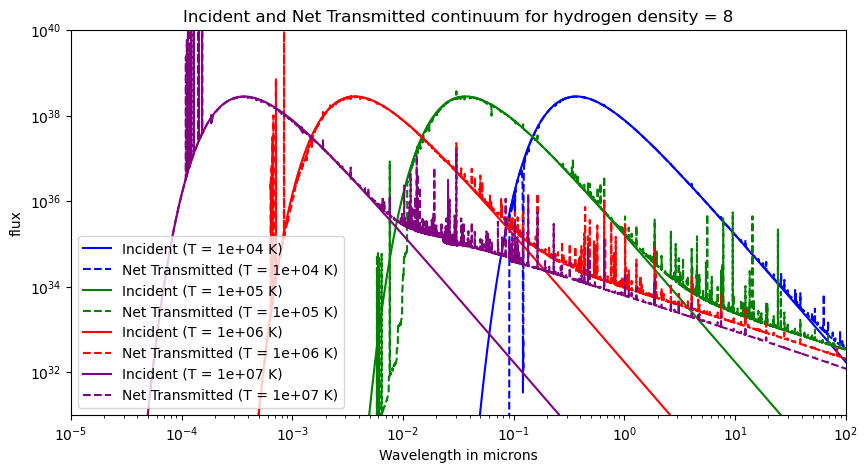

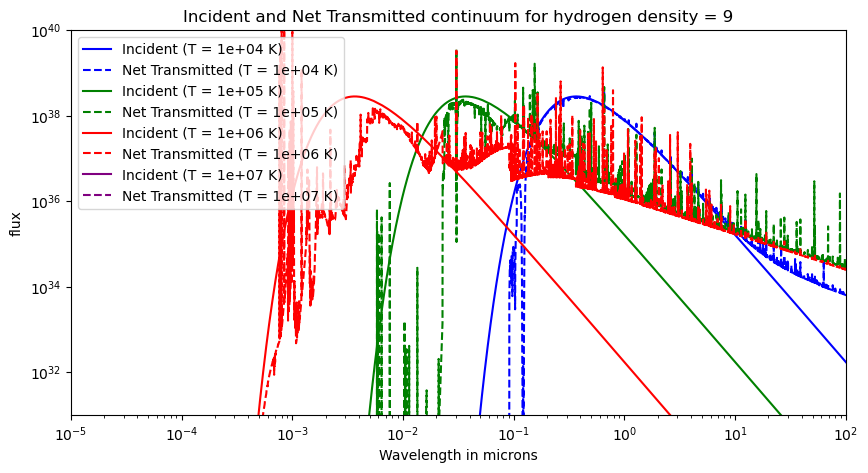

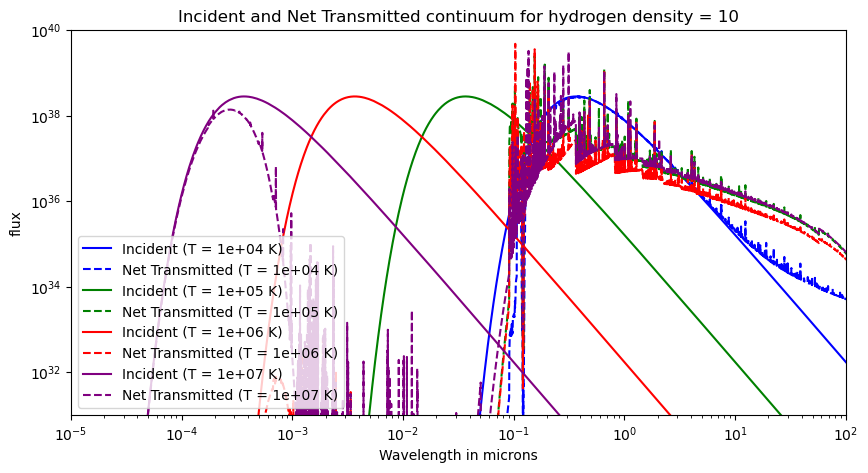

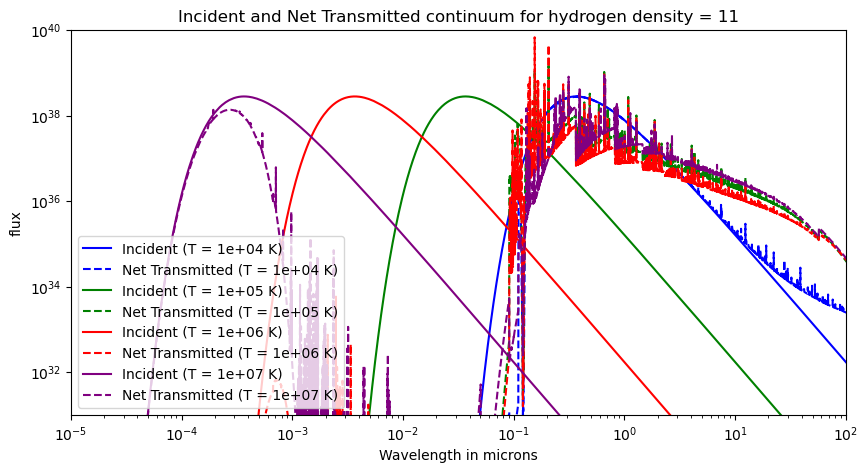

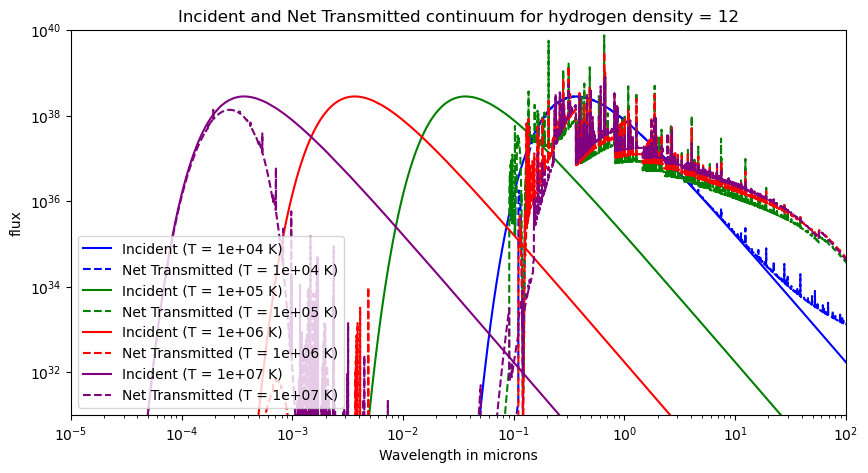

In [8]:
colors = {4: 'blue',5: 'green',6: 'red',7: 'purple'}

for h in range(4, 13):
    
    plt.figure(figsize=(10, 5))
    
    for t in range(4, 8):
        cont = data[h][t].copy()

        energy = cont["#Cont  nu"].to_numpy()
        incident = cont["incident"].to_numpy()
        
        c = colors[t]
        
        cont["net trans"] = cont['net trans'].replace(0, 1e-20)
        net_transmitted = cont["net trans"].to_numpy()
        
        plt.loglog(energy, incident, linestyle='-',color = c, label=f"Incident (T = {10**t:.0e} K)")
        
        plt.loglog(energy, net_transmitted, linestyle='--',color = c, label=f"Net Transmitted (T = {10**t:.0e} K)")

    plt.ylabel("flux")
    plt.xlabel("Wavelength in microns")
    plt.title(f"Incident and Net Transmitted continuum for hydrogen density = {h}")
    plt.ylim(1e31,1e40)
    plt.xlim(1e-5,1e2)

    plt.legend()
    plt.show() 